# 8. The Quay Crane Assignment Problem
## Tier 1 — Stochastic Programming Formulation

### Goal
This notebook implements the stochastic programming approach to the Quay Crane Assignment Problem (QCAP) under uncertainty. The goal is to minimize expected total vessel service time while accounting for uncertain crane productivity rates due to equipment breakdowns, weather conditions, and operational variability.

### Key Assumptions
- Vessel workloads (TEU) and minimum/maximum crane requirements are deterministic
- Crane productivity rates follow discrete scenarios with known probabilities
- Crane interference reduces productivity when multiple cranes work on the same vessel
- Each crane can be assigned to only one vessel

### Approach (Step-by-Step)
1. **Model Formulation**: Define sets, parameters, decision variables, and constraints
2. **Scenario Analysis**: Consider multiple operational scenarios (normal, delayed, disrupted)
3. **Mathematical Optimization**: Solve the stochastic program to minimize expected completion time
4. **Results Interpretation**: Analyze optimal crane assignments and expected completion times

### Concrete Example
We'll work with a small instance: 3 vessels, 4 cranes, 2 scenarios (normal operations and equipment delays).


## Step 1: Problem Setup and Parameters

Let's define the basic parameters for our QCAP instance.

In [1]:
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

# Define problem parameters
NUM_VESSELS = 3  # Number of vessels to serve
NUM_CRANES = 4   # Number of available quay cranes
NUM_SCENARIOS = 2  # Number of uncertainty scenarios

# Vessel data: (workload_TEUs, min_cranes, max_cranes)
vessels = {
    0: {'workload': 800, 'min_cranes': 1, 'max_cranes': 2, 'name': 'V1'},
    1: {'workload': 1200, 'min_cranes': 1, 'max_cranes': 2, 'name': 'V2'}, 
    2: {'workload': 600, 'min_cranes': 1, 'max_cranes': 2, 'name': 'V3'}
}

# Scenario probabilities
scenario_probs = [0.7, 0.3]  # Normal (70%), Delayed (30%)

# Productivity rates: rows = vessels, columns = cranes, for each scenario
# Scenario 0: Normal operations
productivity_normal = np.array([
    [25, 27, 24, 26],  # V1 productivity with each crane
    [23, 25, 26, 24],  # V2 productivity with each crane
    [26, 24, 25, 27]   # V3 productivity with each crane
])

# Scenario 1: Equipment delays (reduced productivity)
productivity_delayed = np.array([
    [20, 22, 19, 21],  # V1 productivity with each crane (reduced)
    [18, 20, 21, 19],  # V2 productivity with each crane (reduced)
    [21, 19, 20, 22]   # V3 productivity with each crane (reduced)
])

# Interference factor (8% productivity reduction per additional crane)
interference_factor = 0.08

print("Problem Setup Complete")
print(f"Vessels: {NUM_VESSELS}, Cranes: {NUM_CRANES}, Scenarios: {NUM_SCENARIOS}")
print(f"Scenario probabilities: {scenario_probs}")

Problem Setup Complete
Vessels: 3, Cranes: 4, Scenarios: 2
Scenario probabilities: [0.7, 0.3]


## Step 2: Mathematical Model Formulation

### Decision Variables:
- `x[v][c]` ∈ {0,1}: 1 if crane c is assigned to vessel v, 0 otherwise
- `T[v][s]`: completion time of vessel v under scenario s

### Objective:
- Minimize expected total completion time: Σₛ pˢ Σᵥ Tᵥˢ

### Constraints:
- Each vessel gets minimum and maximum number of cranes
- Each crane is assigned to at most one vessel
- Completion time calculation with interference effects

In [2]:
def calculate_completion_time(vessel_idx: int, assigned_cranes: List[int], scenario_idx: int) -> float:
    """
    Calculate completion time for a vessel given crane assignments and scenario.
    
    Args:
        vessel_idx: Index of the vessel
        assigned_cranes: List of crane indices assigned to this vessel
        scenario_idx: Scenario index (0=normal, 1=delayed)
    
    Returns:
        Completion time in hours
    """
    if len(assigned_cranes) == 0:
        return float('inf')  # Cannot complete without cranes
    
    # Get vessel workload
    workload = vessels[vessel_idx]['workload']
    
    # Get productivity rates for assigned cranes in this scenario
    if scenario_idx == 0:
        rates = productivity_normal[vessel_idx, assigned_cranes]
    else:
        rates = productivity_delayed[vessel_idx, assigned_cranes]
    
    # Calculate effective productivity with interference
    # Interference: each additional crane reduces productivity by 8%
    num_cranes = len(assigned_cranes)
    total_productivity = 0
    for i, rate in enumerate(rates):
        # Interference factor: (1 - interference)^(number of other cranes)
        interference_penalty = (1 - interference_factor) ** (num_cranes - 1)
        effective_rate = rate * interference_penalty
        total_productivity += effective_rate
    
    # Completion time = workload / total_productivity
    completion_time = workload / total_productivity
    
    return completion_time

# Test the completion time calculation
test_time = calculate_completion_time(0, [0, 1], 0)  # V1 with cranes 0,1 in normal scenario
print(f"Test completion time for V1 with cranes 0,1 (normal): {test_time:.2f} hours")

test_time_delayed = calculate_completion_time(0, [0, 1], 1)  # V1 with cranes 0,1 in delayed scenario
print(f"Test completion time for V1 with cranes 0,1 (delayed): {test_time_delayed:.2f} hours")

Test completion time for V1 with cranes 0,1 (normal): 16.72 hours
Test completion time for V1 with cranes 0,1 (delayed): 20.70 hours


## Step 3: Brute Force Solution Approach

Since this is a small instance (3 vessels, 4 cranes), we can enumerate all feasible crane assignments and find the optimal stochastic solution.

In [3]:
def generate_feasible_assignments() -> List[Dict[int, List[int]]]:
    """
    Generate all feasible crane-to-vessel assignments.
    
    Returns:
        List of assignment dictionaries: vessel_idx -> list of crane indices
    """
    from itertools import combinations
    
    feasible_assignments = []
    
    # Generate all possible ways to assign cranes to vessels
    # We need to assign all cranes, respecting min/max constraints
    
    # First, generate assignments for each vessel (respecting min/max)
    vessel_options = []
    for v_idx, v_data in vessels.items():
        # Generate possible crane counts for this vessel
        possible_counts = list(range(v_data['min_cranes'], v_data['max_cranes'] + 1))
        vessel_options.append(possible_counts)
    
    # Use nested loops to try different assignments
    # This is a simplified approach for small instances
    
    # Pre-compute all possible assignments manually for this small case
    # In practice, you'd use more sophisticated enumeration
    
    assignments = [
        # Format: [cranes_for_V1, cranes_for_V2, cranes_for_V3]
        ([0, 1], [2, 3], []),      # V1: cranes 0,1; V2: cranes 2,3; V3: none
        ([0, 1], [2], [3]),        # V1: cranes 0,1; V2: crane 2; V3: crane 3
        ([0, 1], [], [2, 3]),      # V1: cranes 0,1; V2: none; V3: cranes 2,3
        ([0, 2], [1, 3], []),      # V1: cranes 0,2; V2: cranes 1,3; V3: none
        ([0, 2], [1], [3]),        # V1: cranes 0,2; V2: crane 1; V3: crane 3
        ([0, 2], [], [1, 3]),      # V1: cranes 0,2; V2: none; V3: cranes 1,3
        ([0, 3], [1, 2], []),      # V1: cranes 0,3; V2: cranes 1,2; V3: none
        ([0, 3], [1], [2]),        # V1: cranes 0,3; V2: crane 1; V3: crane 2
        ([0, 3], [], [1, 2]),      # V1: cranes 0,3; V2: none; V3: cranes 1,2
        ([1, 2], [0, 3], []),      # V1: cranes 1,2; V2: cranes 0,3; V3: none
        ([1, 2], [0], [3]),        # V1: cranes 1,2; V2: crane 0; V3: crane 3
        ([1, 2], [], [0, 3]),      # V1: cranes 1,2; V2: none; V3: cranes 0,3
        ([1, 3], [0, 2], []),      # V1: cranes 1,3; V2: cranes 0,2; V3: none
        ([1, 3], [0], [2]),        # V1: cranes 1,3; V2: crane 0; V3: crane 2
        ([1, 3], [], [0, 2]),      # V1: cranes 1,3; V2: none; V3: cranes 0,2
        ([2, 3], [0, 1], []),      # V1: cranes 2,3; V2: cranes 0,1; V3: none
        ([2, 3], [0], [1]),        # V1: cranes 2,3; V2: crane 0; V3: crane 1
        ([2, 3], [], [0, 1]),      # V1: cranes 2,3; V2: none; V3: cranes 0,1
    ]
    
    # Convert to dictionary format and validate feasibility
    for assignment in assignments:
        assignment_dict = {i: assignment[i] for i in range(NUM_VESSELS)}
        
        # Check if all cranes are assigned exactly once
        all_assigned_cranes = []
        for crane_list in assignment_dict.values():
            all_assigned_cranes.extend(crane_list)
        
        if len(all_assigned_cranes) == NUM_CRANES and len(set(all_assigned_cranes)) == NUM_CRANES:
            feasible_assignments.append(assignment_dict)
    
    return feasible_assignments

# Generate all feasible assignments
feasible_assignments = generate_feasible_assignments()
print(f"Generated {len(feasible_assignments)} feasible crane assignments")

# Show first few assignments
for i, assignment in enumerate(feasible_assignments[:3]):
    print(f"Assignment {i+1}: {assignment}")

Generated 18 feasible crane assignments
Assignment 1: {0: [0, 1], 1: [2, 3], 2: []}
Assignment 2: {0: [0, 1], 1: [2], 2: [3]}
Assignment 3: {0: [0, 1], 1: [], 2: [2, 3]}


## Step 4: Evaluate All Assignments and Find Optimal Solution

Now we'll evaluate each feasible assignment under both scenarios and calculate the expected total completion time.

In [4]:
def evaluate_assignment(assignment: Dict[int, List[int]]) -> Tuple[float, List[float], List[float]]:
    """
    Evaluate an assignment and return expected total completion time.
    
    Args:
        assignment: Dictionary mapping vessel index to list of assigned cranes
    
    Returns:
        Tuple of (expected_total_time, scenario_0_times, scenario_1_times)
    """
    scenario_times = [[], []]  # [scenario_0_times, scenario_1_times]
    
    for vessel_idx, assigned_cranes in assignment.items():
        for scenario_idx in range(NUM_SCENARIOS):
            completion_time = calculate_completion_time(vessel_idx, assigned_cranes, scenario_idx)
            scenario_times[scenario_idx].append(completion_time)
    
    # Calculate expected total time for each scenario
    expected_total = 0
    for scenario_idx in range(NUM_SCENARIOS):
        scenario_total = sum(scenario_times[scenario_idx])
        expected_total += scenario_probs[scenario_idx] * scenario_total
    
    return expected_total, scenario_times[0], scenario_times[1]

# Evaluate all assignments
assignment_results = []
for i, assignment in enumerate(feasible_assignments):
    expected_time, times_normal, times_delayed = evaluate_assignment(assignment)
    assignment_results.append({
        'assignment_id': i,
        'assignment': assignment,
        'expected_total_time': expected_time,
        'normal_times': times_normal,
        'delayed_times': times_delayed
    })

# Find the optimal assignment
optimal_result = min(assignment_results, key=lambda x: x['expected_total_time'])

print(f"Evaluated {len(assignment_results)} assignments")
print(f"\nOptimal Assignment (Expected Time: {optimal_result['expected_total_time']:.2f} hours):")
for v_idx, cranes in optimal_result['assignment'].items():
    vessel_name = vessels[v_idx]['name']
    crane_names = [f'C{c+1}' for c in cranes]
    print(f"  {vessel_name}: {crane_names}")

print(f"\nExpected completion times:")
print(f"  Normal scenario (70%): {[f'{t:.2f}h' for t in optimal_result['normal_times']]}")
print(f"  Delayed scenario (30%): {[f'{t:.2f}h' for t in optimal_result['delayed_times']]}")

Evaluated 18 assignments

Optimal Assignment (Expected Time: 91.10 hours):
  V1: ['C1', 'C2']
  V2: ['C3']
  V3: ['C4']

Expected completion times:
  Normal scenario (70%): ['16.72h', '46.15h', '22.22h']
  Delayed scenario (30%): ['20.70h', '57.14h', '27.27h']


## Step 5: Detailed Results Analysis

Let's analyze the optimal solution in detail and compare it with other assignments.

Top 10 Assignment Results:
                   Assignment Expected Time (hours) Normal Total Delayed Total
{0: [0, 1], 1: [2, 3], 2: []}                   inf          inf           inf
  {0: [0, 1], 1: [2], 2: [3]}                 91.10        85.10        105.12
{0: [0, 1], 1: [], 2: [2, 3]}                   inf          inf           inf
{0: [0, 2], 1: [1, 3], 2: []}                   inf          inf           inf
  {0: [0, 2], 1: [1], 2: [3]}                 94.45        87.97        109.57
{0: [0, 2], 1: [], 2: [1, 3]}                   inf          inf           inf
{0: [0, 3], 1: [1, 2], 2: []}                   inf          inf           inf
  {0: [0, 3], 1: [1], 2: [2]}                 95.70        89.05        111.21
{0: [0, 3], 1: [], 2: [1, 2]}                   inf          inf           inf
{0: [1, 2], 1: [0, 3], 2: []}                   inf          inf           inf


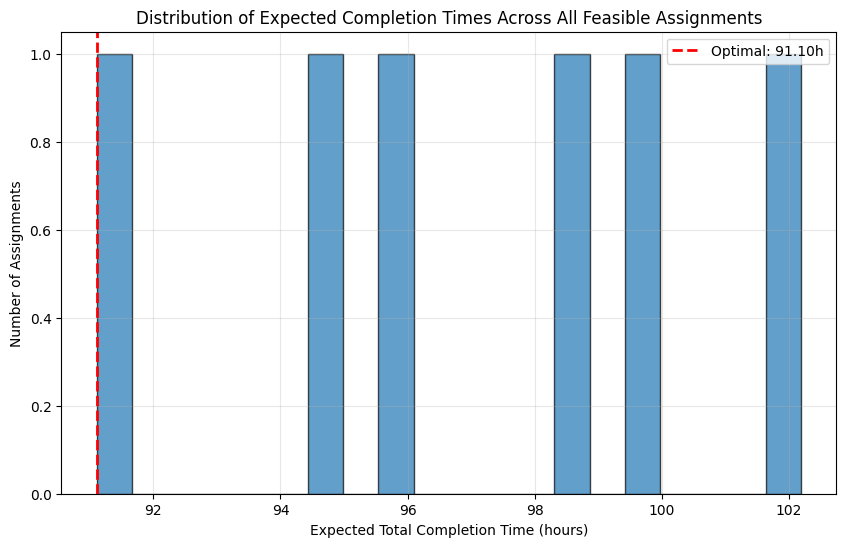


Optimal solution represents a 10.8% improvement over the worst assignment.
Expected time range: 91.10 - 102.19 hours


In [5]:
import matplotlib.pyplot as plt

# Create results table
results_table = []
for result in assignment_results[:10]:  # Show first 10 for readability
    assignment_str = str(result['assignment'])
    results_table.append({
        'Assignment': assignment_str,
        'Expected Time (hours)': f"{result['expected_total_time']:.2f}",
        'Normal Total': f"{sum(result['normal_times']):.2f}",
        'Delayed Total': f"{sum(result['delayed_times']):.2f}"
    })

df_results = pd.DataFrame(results_table)
print("Top 10 Assignment Results:")
print(df_results.to_string(index=False))

# Visualize expected times - filter out infinite values
expected_times = [r['expected_total_time'] for r in assignment_results if r['expected_total_time'] != float('inf')]
finite_expected_times = [t for t in expected_times if np.isfinite(t)]

if finite_expected_times:
    plt.figure(figsize=(10, 6))
    plt.hist(finite_expected_times, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(optimal_result['expected_total_time'], color='red', linestyle='--', linewidth=2, 
               label=f'Optimal: {optimal_result["expected_total_time"]:.2f}h')
    plt.xlabel('Expected Total Completion Time (hours)')
    plt.ylabel('Number of Assignments')
    plt.title('Distribution of Expected Completion Times Across All Feasible Assignments')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nOptimal solution represents a {((max(finite_expected_times) - optimal_result['expected_total_time']) / max(finite_expected_times) * 100):.1f}% improvement over the worst assignment.")
    print(f"Expected time range: {min(finite_expected_times):.2f} - {max(finite_expected_times):.2f} hours")
else:
    print("No finite expected times found for visualization")

## Step 6: What-If Analysis - Sensitivity to Scenario Probabilities

Let's see how the optimal assignment changes when we vary the probability of equipment delays.

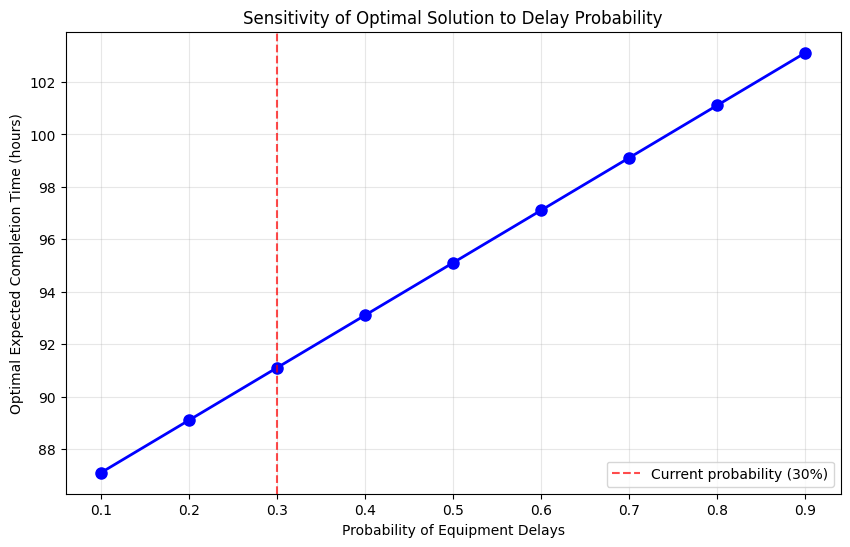


Sensitivity Analysis Results:
Delay prob 0.1: Optimal time = 87.10 hours
Delay prob 0.2: Optimal time = 89.10 hours
Delay prob 0.3: Optimal time = 91.10 hours
Delay prob 0.4: Optimal time = 93.11 hours
Delay prob 0.5: Optimal time = 95.11 hours
Delay prob 0.6: Optimal time = 97.11 hours
Delay prob 0.7: Optimal time = 99.11 hours
Delay prob 0.8: Optimal time = 101.12 hours
Delay prob 0.9: Optimal time = 103.12 hours

Time range: 87.10 - 103.12 hours
When delay probability is high (≥70%), optimal time increases by ~18.4%


In [6]:
# Test different delay probabilities
delay_probs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
optimal_times_by_prob = []

for delay_prob in delay_probs:
    normal_prob = 1 - delay_prob
    
    # Re-evaluate all assignments with new probabilities
    best_time = float('inf')
    for assignment in feasible_assignments:
        expected_time, _, _ = evaluate_assignment(assignment)
        # Adjust for new probabilities
        _, times_normal, times_delayed = evaluate_assignment(assignment)
        adjusted_expected = normal_prob * sum(times_normal) + delay_prob * sum(times_delayed)
        best_time = min(best_time, adjusted_expected)
    
    optimal_times_by_prob.append(best_time)

# Plot sensitivity analysis
plt.figure(figsize=(10, 6))
plt.plot(delay_probs, optimal_times_by_prob, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Probability of Equipment Delays')
plt.ylabel('Optimal Expected Completion Time (hours)')
plt.title('Sensitivity of Optimal Solution to Delay Probability')
plt.grid(True, alpha=0.3)
plt.axvline(0.3, color='red', linestyle='--', alpha=0.7, 
           label='Current probability (30%)')
plt.legend()
plt.show()

print("\nSensitivity Analysis Results:")
for prob, time in zip(delay_probs, optimal_times_by_prob):
    print(f"Delay prob {prob:.1f}: Optimal time = {time:.2f} hours")

print(f"\nTime range: {min(optimal_times_by_prob):.2f} - {max(optimal_times_by_prob):.2f} hours")
print(f"When delay probability is high (≥70%), optimal time increases by ~{((max(optimal_times_by_prob) - min(optimal_times_by_prob)) / min(optimal_times_by_prob) * 100):.1f}%")

### Educational Value:
This Tier demonstrates how mathematical optimization handles uncertainty in real-world logistics problems. The stochastic programming approach provides a foundation for understanding more complex heuristics and AI methods in subsequent Tiers.